# Ejercicio 03 · Corpus público y clasificador de texto reproducible

**INF-8239 Ciencia de Datos II · Unidad 02 · LAB04 + LAB05**

**Pregunta:** ¿puede el contenido textual de un SMS predecir si es spam?

**Corpus:** SMS Spam Collection (UCI id 228, CC BY 4.0, DOI 10.24432/C5CC84). Ficha completa en
`docs/DATASET_CARD.md`.

Este notebook reutiliza el código del paquete `inf8239_u02` y **no modifica ningún artefacto**: recalcula
la auditoría, la partición y los modelos, y comprueba que coinciden con lo guardado en `reports/`.

**Requisitos previos** (ver README): `cp .env.example .env`, `uv sync`,
`uv run python scripts/prepare_sms_spam.py` y `uv run python scripts/train_text.py`.
Para reejecutarlo: `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/ejercicio03.ipynb`.

In [1]:
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

from inf8239_u02.config import ROOT, settings
from inf8239_u02.data import load_dataset, sha256, validate_dataframe
from inf8239_u02.modeling import build_models

# Paleta validada (dataviz): color = clase real, en todos los gráficos.
HAM, SPAM = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})
pd.set_option("display.max_colwidth", 110)
TEXT, TARGET = settings.text_column, settings.target_column

## 1 · Trazabilidad del corpus

El SHA-256 debe coincidir con el registrado en la ficha (`c9ca2be9…a022d0`). Si cambia, la fuente cambió.

In [2]:
EXPECTED_SHA = "c9ca2be9b60921499e30de05a0350c9bee1ba7cfc98bc03d1547819938a022d0"
df = load_dataset()
validate_dataframe(df, TEXT, TARGET)
digest = sha256(settings.dataset_path)
print("Archivo:", settings.dataset_path.relative_to(ROOT))
print("SHA-256:", digest)
print("Coincide con la ficha:", digest == EXPECTED_SHA)
assert digest == EXPECTED_SHA

Archivo: data\raw\dataset.csv
SHA-256: c9ca2be9b60921499e30de05a0350c9bee1ba7cfc98bc03d1547819938a022d0
Coincide con la ficha: True


## 2 · Auditoría

In [3]:
text = df[TEXT].astype(str)
audit = pd.Series({
    "Filas": len(df),
    "Columnas": df.shape[1],
    "Nulos en text": int(df[TEXT].isna().sum()),
    "Nulos en label": int(df[TARGET].isna().sum()),
    "Duplicados exactos de texto": int(text.duplicated().sum()),
    "Textos con etiquetas contradictorias": int((df.groupby(TEXT)[TARGET].nunique() > 1).sum()),
}, name="valor")
display(audit.to_frame())
dist = df[TARGET].value_counts()
display(pd.DataFrame({"mensajes": dist, "proporción": (dist / len(df)).round(4)}))
display(text.str.len().describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_frame("longitud (caracteres)").T)

,valor
Filas,5574
Columnas,2
Nulos en text,0
Nulos en label,0
Duplicados exactos de texto,403
Textos con etiquetas contradictorias,0


,mensajes,proporción
label,,
ham,4827,0.866
spam,747,0.134


,count,mean,std,min,50%,90%,99%,max
longitud (caracteres),5574.0,80.5,59.8,2.0,62.0,156.0,276.0,910.0


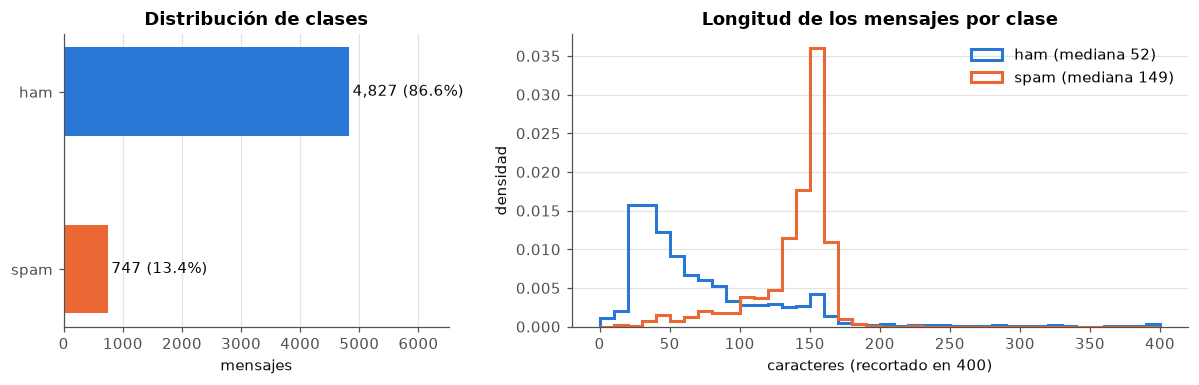

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})

ax1.barh(["spam", "ham"], [dist["spam"], dist["ham"]], color=[SPAM, HAM], height=0.5)
for y, label in enumerate(["spam", "ham"]):
    ax1.text(dist[label] + 60, y, f"{dist[label]:,} ({dist[label] / len(df):.1%})", va="center", color=INK)
ax1.set_xlim(0, dist.max() * 1.35)
ax1.set_title("Distribución de clases")
ax1.set_xlabel("mensajes")
ax1.grid(axis="x", color=GRID, linewidth=0.8)
ax1.set_axisbelow(True)

lengths = df.assign(n=text.str.len())
bins = np.arange(0, 401, 10)
for label, color in [("ham", HAM), ("spam", SPAM)]:
    values = lengths.loc[lengths[TARGET] == label, "n"].clip(upper=400)
    ax2.hist(values, bins=bins, histtype="step", linewidth=2, color=color, density=True,
             label=f"{label} (mediana {values.median():.0f})")
ax2.set_title("Longitud de los mensajes por clase")
ax2.set_xlabel("caracteres (recortado en 400)")
ax2.set_ylabel("densidad")
ax2.legend(frameon=False)
ax2.grid(axis="y", color=GRID, linewidth=0.8)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Lectura.** Sin nulos ni etiquetas contradictorias. El desbalance (86,6 % ham) hace que la *accuracy*
sea engañosa: un modelo que siempre diga `ham` acierta el 86,6 %. El spam es casi tres veces más largo
(mediana 149 frente a 52 caracteres), una señal fuerte y un posible atajo del modelo.

## 3 · Duplicados y prevención de fuga

Los duplicados exactos se eliminan **antes** de dividir, para que un mismo texto no aparezca en
entrenamiento y prueba. La vectorización TF-IDF va **dentro** de cada pipeline, así que solo aprende
el vocabulario del conjunto de entrenamiento.

In [5]:
clean = df.dropna(subset=[TEXT, TARGET]).drop_duplicates(subset=[TEXT])
normalized = (clean[TEXT].str.lower().str.replace(r"[^a-z ]", "", regex=True)
              .str.replace(r"\s+", " ", regex=True).str.strip())
near = normalized.duplicated()
print(f"Tras eliminar duplicados exactos: {len(clean):,} mensajes")
print(f"Casi duplicados restantes (solo difieren en números/puntuación): {near.sum()} "
      f"({clean.loc[near, TARGET].value_counts().to_dict()})")

x_train, x_test, y_train, y_test = train_test_split(
    clean[TEXT], clean[TARGET], test_size=0.25,
    random_state=settings.random_state, stratify=clean[TARGET],
)
split = pd.DataFrame({"entrenamiento": y_train.value_counts(), "prueba": y_test.value_counts()})
split.loc["total"] = split.sum()
split["% spam"] = ""
split.loc["total", "% spam"] = f"{y_train.eq('spam').mean():.1%} / {y_test.eq('spam').mean():.1%}"
display(split)
print("Textos compartidos entre entrenamiento y prueba:", len(set(x_train) & set(x_test)))

Tras eliminar duplicados exactos: 5,171 mensajes
Casi duplicados restantes (solo difieren en números/puntuación): 77 ({'spam': 59, 'ham': 18})


,entrenamiento,prueba,% spam
label,,,
ham,3388,1130,
spam,490,163,
total,3878,1293,12.6% / 12.6%


Textos compartidos entre entrenamiento y prueba: 0


**Lectura.** La partición estratificada conserva la misma proporción de spam en ambos conjuntos y
no comparte ningún texto. Los 77 casi duplicados (59 de spam: plantillas que solo cambian el número)
pueden caer a ambos lados e inflar ligeramente las métricas de spam; se declara como limitación.

## 4 · Baseline y dos pipelines comparables

In [6]:
models = build_models(settings.random_state)
rows, predictions = [], {}
for name, model in models.items():
    pred = model.fit(x_train, y_train).predict(x_test)
    predictions[name] = pred
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    rows.append({
        "modelo": name,
        "F1 macro": f1_score(y_test, pred, average="macro"),
        "accuracy": report["accuracy"],
        "precisión spam": report["spam"]["precision"],
        "recall spam": report["spam"]["recall"],
        "recall ham": report["ham"]["recall"],
    })
metrics = pd.DataFrame(rows).set_index("modelo")
display(metrics.round(3))

saved = pd.read_csv(ROOT / "reports/text_metrics.csv").set_index("model")["f1_macro"]
print("Coincide con reports/text_metrics.csv:", np.allclose(metrics["F1 macro"], saved[metrics.index]))

,F1 macro,accuracy,precisión spam,recall spam,recall ham
modelo,,,,,
dummy,0.466,0.874,0.000,0.000,1.000
naive_bayes,0.926,0.970,0.956,0.798,0.995
logistic,0.956,0.981,0.921,0.926,0.988


Coincide con reports/text_metrics.csv: True


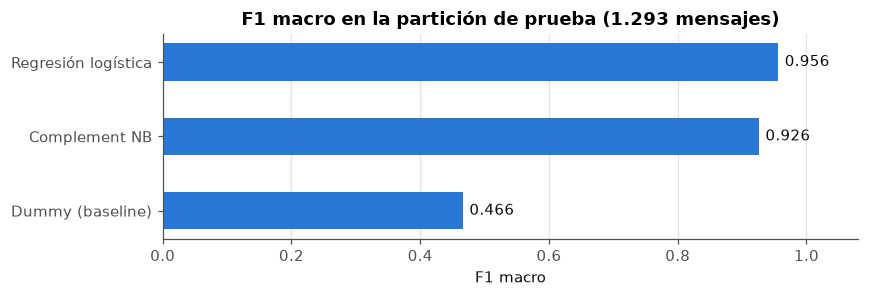

In [7]:
fig, ax = plt.subplots(figsize=(8, 2.8))
order = ["dummy", "naive_bayes", "logistic"]
labels = ["Dummy (baseline)", "Complement NB", "Regresión logística"]
values = metrics.loc[order, "F1 macro"]
ax.barh(labels, values, color=HAM, height=0.5)
for y, v in enumerate(values):
    ax.text(v + 0.01, y, f"{v:.3f}", va="center", color=INK)
ax.set_xlim(0, 1.08)
ax.set_title("F1 macro en la partición de prueba (1.293 mensajes)")
ax.set_xlabel("F1 macro")
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Lectura.** El baseline obtiene 87,4 % de *accuracy* sin detectar un solo spam (F1 macro 0,466). La
regresión logística supera a Naive Bayes por 0,030 de F1 macro, pero la diferencia está en la clase
minoritaria: recupera el 93 % del spam frente al 80 %. Ambos son lineales sobre la misma matriz
TF-IDF, así que la mejora no añade complejidad. Se selecciona la regresión logística.

## 5 · Matrices de confusión

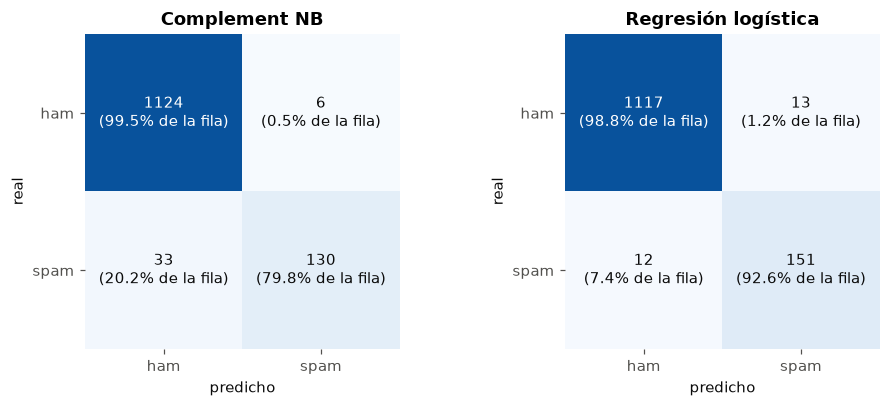

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, name, title in [(axes[0], "naive_bayes", "Complement NB"), (axes[1], "logistic", "Regresión logística")]:
    cm = confusion_matrix(y_test, predictions[name], labels=["ham", "spam"])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max() * 1.15)
    for i in range(2):
        for j in range(2):
            share = cm[i, j] / cm[i].sum()
            ax.text(j, i, f"{cm[i, j]}\n({share:.1%} de la fila)", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else INK)
    ax.set_xticks([0, 1], ["ham", "spam"])
    ax.set_yticks([0, 1], ["ham", "spam"])
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

**Lectura (modelo seleccionado).** 13 mensajes legítimos se marcan como spam (falsos positivos) y 12
spam pasan como legítimos (falsos negativos). En un filtro, el falso positivo es más grave porque el
usuario no ve el mensaje perdido; el falso negativo lo expone a llamadas de tarificación adicional.
Naive Bayes casi no genera falsos positivos (6), pero deja pasar 33 spam.

## 6 · Análisis de los errores

`reports/error_analysis.csv` contiene los 25 errores de la regresión logística, clasificados a mano
(columna `category`) con su justificación (`note`). Los números telefónicos están sustituidos por
`[TELÉFONO]` y el nombre propio por `[NOMBRE]`.

In [9]:
errors = pd.read_csv(ROOT / "reports/error_analysis.csv")
logistic_errors = x_test[y_test != predictions["logistic"]]
print("Errores en reports/:", len(errors), "| errores recalculados:", len(logistic_errors))
assert len(errors) == len(logistic_errors) and "REVISAR" not in set(errors["category"])

errors["tipo"] = np.where(errors["real"] == "ham", "ham → spam (FP)", "spam → ham (FN)")
table = pd.crosstab(errors["category"], errors["tipo"], margins=True, margins_name="Total")
table = table.sort_values("Total", ascending=False)
display(table)

Errores en reports/: 25 | errores recalculados: 25


tipo,ham → spam (FP),spam → ham (FN),Total
category,,,
Total,13,12,25
ambigüedad,9,3,12
dialecto,0,3,3
etiqueta discutible,2,1,3
tema fuera del dominio,0,3,3
texto insuficiente,2,1,3
ironía,0,1,1


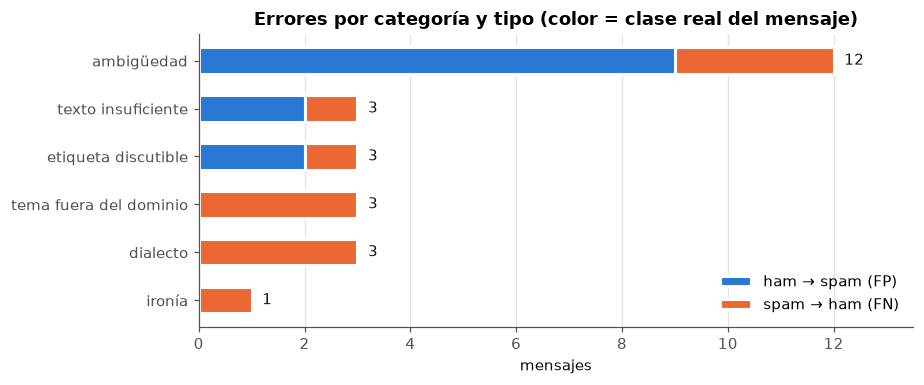

In [10]:
counts = table.drop(index="Total").drop(columns="Total").sort_values(
    ["ham → spam (FP)", "spam → ham (FN)"], ascending=True)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
left = np.zeros(len(counts))
for column, color in [("ham → spam (FP)", HAM), ("spam → ham (FN)", SPAM)]:
    ax.barh(counts.index, counts[column], left=left, color=color, height=0.55,
            edgecolor="white", linewidth=2, label=column)
    left += counts[column].to_numpy()
for y, total in enumerate(left):
    ax.text(total + 0.2, y, str(int(total)), va="center", color=INK)
ax.set_title("Errores por categoría y tipo (color = clase real del mensaje)")
ax.set_xlabel("mensajes")
ax.set_xlim(0, left.max() + 1.5)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [11]:
display(errors[["text", "real", "predicted", "category", "note"]])

,text,real,predicted,category,note
0,I am waiting for your call sir.,ham,spam,ambigüedad,Petición de llamada: 'call' domina y es muy frecuente en spam ('Call 0871…')
1,Your daily text from me – a favour this time,ham,spam,ambigüedad,'daily text' y 'favour' evocan suscripciones y servicios por SMS
2,Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super w...,spam,ham,ambigüedad,"Promoción de marca sin marcadores típicos (sin número, precio ni 'free/win' salvo 'winner')"
3,I'm at work. Please call,ham,spam,ambigüedad,Petición de llamada corta: 'please call' es patrón típico de spam
4,Want explicit SEX in 30 secs? Ring [TELÉFONO] now! Costs 20p/min,spam,ham,tema fuera del dominio,Spam de contenido adulto con número premium; subtema poco frecuente frente a premios/concursos
5,Missed call alert. These numbers called but left no message. [TELÉFONO],spam,ham,ambigüedad,Imita una notificación legítima del operador ('Missed call alert')
6,Money i have won wining number 946 wot do i do next,spam,ham,dialecto,"Jerga y faltas ('wot', 'wining') propias del ham informal"
7,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day,...",spam,ham,ambigüedad,Parece trivia entre amigos; sin premio ni número explícito
8,ringtoneking 84484,spam,ham,texto insuficiente,Solo una palabra y un código corto; muy poca evidencia para TF-IDF
9,Plz note: if anyone calling from a mobile Co. &amp; asks u to type # &lt;#&gt; or # &lt;#&gt; . Do not do...,ham,spam,etiqueta discutible,Cadena viral de advertencia (hoax) etiquetada ham; su forma es de mensaje masivo


**Lectura.** La ambigüedad por vocabulario compartido explica 12 de 25 errores y 9 de los 13 falsos
positivos: mensajes legítimos con *call*, *free* u *offer*, que en este corpus son marcas típicas del
spam. Los falsos negativos son spam escrito como mensaje informal (dialecto) o de temas poco
representados. Tres etiquetas son discutibles: parte del error medido pertenece al corpus.

**Hipótesis para el siguiente experimento:** sustituir los números por un marcador y añadir n-gramas
de caracteres debería reducir los falsos positivos por ambigüedad sin aumentar los falsos negativos.

## 7 · Pruebas automatizadas

In [12]:
result = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT, capture_output=True, text=True)
print(result.stdout.strip().splitlines()[-1])

9 passed in 2.42s


## Conclusión

La regresión logística sobre TF-IDF clasifica SMS en inglés con F1 macro 0,956, frente a 0,926 de
Naive Bayes y 0,466 del baseline. Los resultados coinciden con los artefactos de `reports/`, y la
partición no comparte textos entre entrenamiento y prueba. El modelo **solo es válido para SMS en
inglés de Reino Unido y Singapur hasta 2011**: no debe usarse con mensajes en español ni para
bloquear mensajes, sino para marcar "posible spam". La conclusión completa está en el README.